In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [2]:
from unsloth import FastLanguageModel
import torch
from datasets import load_dataset
import json

# --- STEP 1: LOAD MODEL ---
max_seq_length = 2048
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen3-8B-Base",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-03-04 05:03:56.450819: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772600636.877614      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772600636.984673      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772600638.013280      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772600638.013324      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772600638.013327      55 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.3: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/6.75G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

unsloth/qwen3-8b-base-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [3]:
# --- STEP 2: PREPARE DATASET ---
from datasets import load_dataset

# 1. Define your prompt template
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]
    texts = []
    for inst, inp, out in zip(instructions, inputs, outputs):
        # Format the text and add the EOS token
        text = alpaca_prompt.format(inst, inp, out) + tokenizer.eos_token
        texts.append(text)
    return { "text" : texts }

# 2. LOAD SEPARATE FILES DIRECTLY
# Replace these paths with the actual locations of your split files
dataset = load_dataset("json", data_files={
    "train": "/kaggle/input/datasets/adarsha100/trainingset/training.json", 
    "test":  "/kaggle/input/datasets/adarsha100/testingset/testing.json"
})

# 3. Apply the mapping to both sets
train_dataset = dataset["train"].map(formatting_prompts_func, batched = True)
eval_dataset  = dataset["test"].map(formatting_prompts_func, batched = True)

# Keep a raw copy of test data for manual evaluation/scoring later
eval_dataset_raw = dataset["test"]

print(f"Dataset loaded. Train size: {len(train_dataset)}, Test size: {len(eval_dataset)}")

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/9000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset loaded. Train size: 9000, Test size: 1000


In [4]:
!pip install evaluate sacrebleu rouge-score bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.0 MB/s eta 0:00:00


In [5]:
from tqdm import tqdm
from evaluate import load
from bert_score import score as bert_score_fn
import math
import torch

def run_evaluation(model, tokenizer, dataset, title="Model"):
    print(f"\n🚀 Starting Evaluation: {title}")
    total_samples = len(dataset)

    # Load metrics
    bleu = load("bleu")
    chrf = load("chrf")
    rouge = load("rouge")

    predictions, references, total_loss = [], [], 0.0

    # Using enumerate for the sample counter
    for i, row in enumerate(tqdm(dataset, desc="Processing")):
        # 1. Generate Response (Hidden from print)
        prompt = alpaca_prompt.format(row['instruction'], row['input'], "")
        inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

        # We use a modest max_new_tokens to speed up base model testing
        outputs = model.generate(**inputs, max_new_tokens=128, use_cache=True)
        resp = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("### Response:")[-1].strip()

        predictions.append(resp)
        references.append(row['output'])

        # 2. Perplexity Calculation
        full_text = alpaca_prompt.format(row['instruction'], row['input'], row['output'])
        encodings = tokenizer(full_text, return_tensors="pt").to("cuda")
        with torch.no_grad():
            loss = model(**encodings, labels=encodings["input_ids"]).loss
            total_loss += loss.item()

        # 3. Progress Print (Shows count only)
        # Using end="\r" keeps it on one line to keep the console clean
        print(f"✅ Sample {i+1}/{total_samples} done", end="\r")

    # 4. Final Calculations
    print(f"\n\n🧮 Calculating final scores for {title}...")

    # Perplexity Formula: $PPL = e^{(\frac{1}{N}\sum loss)}$
    ppl = math.exp(total_loss / total_samples)

    # BERTScore
    _, _, b_f1 = bert_score_fn(predictions, references, lang="bert-base-multilingual-cased")

    # Compute Standard Metrics
    rouge_results = rouge.compute(predictions=predictions, references=references)
    bleu_results = bleu.compute(predictions=predictions, references=[[r] for r in references])
    chrf_results = chrf.compute(predictions=predictions, references=[[r] for r in references], word_order=2)

    results = {
        "PPL": ppl,
        "BERT": b_f1.mean().item(),
        "BLEU": bleu_results['bleu'],
        "chrF++": chrf_results['score'],
        "ROUGE-1": rouge_results['rouge1'],
        "ROUGE-2": rouge_results['rouge2'],
        "ROUGE-L": rouge_results['rougeL']
    }

    print(f"✨ Evaluation Complete for {title}!")
    for metric, value in results.items():
        print(f"🔹 {metric}: {value:.4f}")

    return results

# Get Baseline
base_results = run_evaluation(model, tokenizer, eval_dataset_raw, "Base Model")


🚀 Starting Evaluation: Base Model


Processing:   0%|          | 1/1000 [00:38<10:47:39, 38.90s/it]

Processing:   0%|          | 2/1000 [00:46<5:44:23, 20.71s/it] 

Processing:   0%|          | 3/1000 [00:55<4:09:21, 15.01s/it]

Processing:   0%|          | 4/1000 [01:03<3:24:32, 12.32s/it]

...

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

✨ Evaluation Complete for Base Model!
🔹 PPL: 27.8920
🔹 BERT: 0.5631
🔹 BLEU: 0.0099
🔹 chrF++: 13.1024
🔹 ROUGE-1: 0.0570
🔹 ROUGE-2: 0.0195
🔹 ROUGE-L: 0.0513


In [6]:
from transformers import TextStreamer

# 1. Switch to Inference Mode (Vital for Unsloth speed)
FastLanguageModel.for_inference(model)

# 2. Prepare the Prompt
instruction = "nepal ko barema bhanata"
input_context = "" # Leave empty if not needed

formatted_prompt = alpaca_prompt.format(instruction, input_context, "")

# 3. Tokenize
inputs = tokenizer([formatted_prompt], return_tensors = "pt").to("cuda")

# 4. Set up the Streamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True) # skip_prompt=True hides your input

# 5. Generate with Parameters
_ = model.generate(
    **inputs,
    streamer = text_streamer,
    max_new_tokens = 256,       # Increased for more detailed answers
    temperature = 0.3,          # Lower = more focused; Higher = more creative
    repetition_penalty = 1.1,   # Prevents the model from getting "stuck"
    use_cache = True
)

Nepal is a landlocked country located in South Asia and bordered by India to its south and east, China to its north, Bhutan to its west, and Bangladesh to its southeast. It has a population of approximately 30 million people and covers an area of about 147,582 square kilometers (56,982 sq mi). The capital city is Kathmandu which serves as both political center for government activities as well as commercial hub where many businesses operate from there too!<|endoftext|>


In [7]:
base_results

{'PPL': 27.89203165266233,
 'BERT': 0.5631071925163269,
 'BLEU': 0.009877552379714412,
 'chrF++': 13.10238577414513,
 'ROUGE-1': np.float64(0.056993642216806396),
 'ROUGE-2': np.float64(0.019513663604078697),
 'ROUGE-L': np.float64(0.05132178648033645)}

In [8]:
from trl import SFTConfig, SFTTrainer

# 1. PEFT Model (Kept exactly as provided)
model = FastLanguageModel.get_peft_model(
model,
r = 32,
target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
lora_alpha = 64,
lora_dropout = 0,
bias = "none",
use_rslora = True,
)

# 2. Configuration & Trainer
trainer = SFTTrainer(
model = model,
tokenizer = tokenizer,
train_dataset = train_dataset,
eval_dataset = eval_dataset,
dataset_text_field = "text",
args = SFTConfig(
max_seq_length = max_seq_length,
per_device_train_batch_size = 2,
gradient_accumulation_steps = 4,
warmup_steps = 200,
num_train_epochs = 3,
learning_rate = 1e-4,
fp16 = not torch.cuda.is_bf16_supported(),
bf16 = torch.cuda.is_bf16_supported(),
logging_steps = 1,
eval_strategy = "steps",
eval_steps = 100,

# --- NEW CHECKPOINT SETTINGS ADDED BELOW ---
save_strategy = "steps", # Save based on step count
save_steps = 100, # Save a checkpoint every 100 steps (matches eval)
save_total_limit = 10, # Keeps the 10 best/most recent checkpoints to save disk space
load_best_model_at_end = True, # Automatically loads the "Golden Point" weights when finished
metric_for_best_model = "eval_loss",
# -------------------------------------------

optim = "adamw_8bit",
output_dir = "outputs",
),
)

Unsloth 2026.3.3 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/9000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/1000 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [9]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,000 | Num Epochs = 3 | Total steps = 3,375
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 87,293,952 of 8,278,029,312 (1.05% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,2.199400,1.921190
200,2.092800,1.719999
300,1.895500,1.555720
400,1.321100,1.471993
500,1.368200,1.397076
600,1.650500,1.354219
700,1.389800,1.313921
800,1.300200,1.282518
900,0.936700,1.263208
1000,1.380800,1.230268


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=3375, training_loss=1.043093777038433, metrics={'train_runtime': 30372.207, 'train_samples_per_second': 0.889, 'train_steps_per_second': 0.111, 'total_flos': 2.2597847140698317e+17, 'train_loss': 1.043093777038433, 'epoch': 3.0})

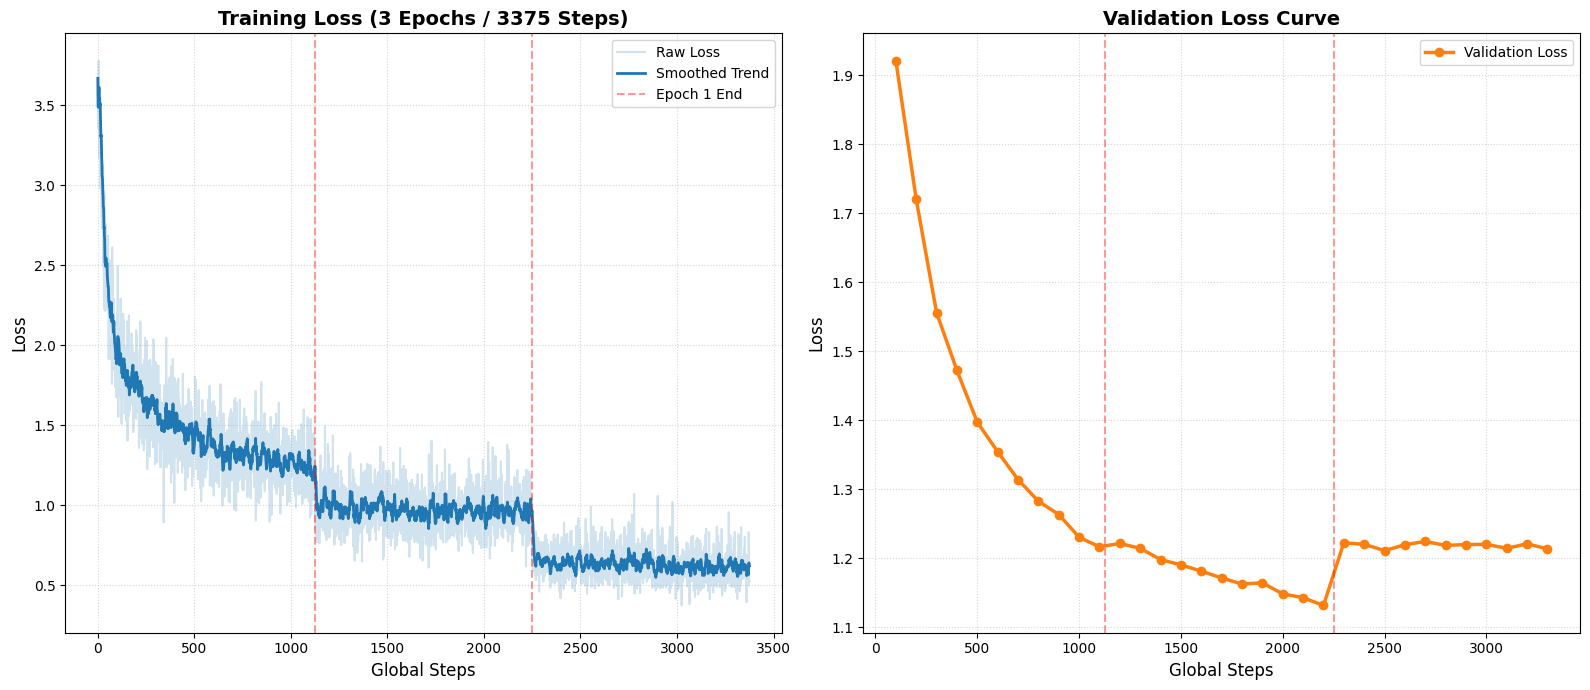

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_refined_losses(trainer, num_epochs=3):
    # 1. Extract raw logs
    history = trainer.state.log_history
    train_data = [x for x in history if 'loss' in x]
    eval_data = [x for x in history if 'eval_loss' in x]

    if not train_data:
        print("❌ No training data found. Did the model actually train?")
        return

    # 2. Prepare Training Data with Smoothing
    train_steps = [x['step'] for x in train_data]
    train_losses = [x['loss'] for x in train_data]

    # Apply Smoothing (Moving Average) to see the trend through the noise
    # Window size 10 means it averages the last 10 steps
    train_smooth = pd.Series(train_losses).rolling(window=10, min_periods=1).mean()

    # 3. Prepare Validation Data
    eval_steps = [x['step'] for x in eval_data]
    eval_losses = [x['eval_loss'] for x in eval_data]

    # 4. Calculate Epoch Markers
    total_steps = max(train_steps)
    steps_per_epoch = total_steps // num_epochs

    # 5. Create the Visuals
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # --- Plot 1: Training Loss (Raw + Smooth) ---
    ax1.plot(train_steps, train_losses, color='#1f77b4', alpha=0.2, label='Raw Loss')
    ax1.plot(train_steps, train_smooth, color='#1f77b4', lw=2, label='Smoothed Trend')

    # Add Epoch Vertical Lines
    for i in range(1, num_epochs):
        ax1.axvline(x=steps_per_epoch * i, color='red', linestyle='--', alpha=0.4, label=f'Epoch {i} End' if i==1 else "")

    ax1.set_title(f'Training Loss (3 Epochs / {total_steps} Steps)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Global Steps', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.grid(True, linestyle=':', alpha=0.5)
    ax1.legend()

    # --- Plot 2: Validation Loss ---
    if eval_losses:
        ax2.plot(eval_steps, eval_losses, color='#ff7f0e', lw=2.5, marker='o', markersize=6, label='Validation Loss')

        # Add Epoch Vertical Lines
        for i in range(1, num_epochs):
            ax2.axvline(x=steps_per_epoch * i, color='red', linestyle='--', alpha=0.4)

        ax2.set_title('Validation Loss Curve', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Global Steps', fontsize=12)
        ax2.set_ylabel('Loss', fontsize=12)
        ax2.grid(True, linestyle=':', alpha=0.5)
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'Validation data only appears\nevery 100 steps (eval_steps)',
                 ha='center', va='center', fontsize=12, color='gray')

    # 6. Save and Display
    plt.tight_layout()
    plt.savefig("roman_nepali_training_report.png", dpi=300)
    plt.show()

# Run it!
plot_refined_losses(trainer, num_epochs=3)

In [11]:
from transformers import TextStreamer

# 1. Switch to Inference Mode (Vital for Unsloth speed)
FastLanguageModel.for_inference(model)

# 2. Prepare the Prompt
instruction = "nepal ko barema bhanta"
input_context = "" # Leave empty if not needed

formatted_prompt = alpaca_prompt.format(instruction, input_context, "")

# 3. Tokenize
inputs = tokenizer([formatted_prompt], return_tensors = "pt").to("cuda")

# 4. Set up the Streamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True) # skip_prompt=True hides your input

# 5. Generate with Parameters
_ = model.generate(
    **inputs,
    streamer = text_streamer,
    max_new_tokens = 256,       # Increased for more detailed answers
    temperature = 0.3,          # Lower = more focused; Higher = more creative
    repetition_penalty = 1.1,   # Prevents the model from getting "stuck"
    use_cache = True
)

nepala purvi himali kshetra ma avasthita eka bhumadhyasara desha ho| yo 24 parvataharu samga samsarako sabaibhanda aglo jvalamukhi ra sabaibhanda lamo nadiharuko ghara ho| yasama dherai prakaraka vanyajantuharu chan, jasama hatti, simha, bagha, chamari ra chituvaharu samavesha chan| nepalako rajadhani katima cha, juna pashchimi tirtha marga marphata chinabata lagabhaga 150 kilomitara tadha avasthita cha|<|endoftext|>


In [ ]:
# Save just the adapters to Hugging Face
model.push_to_hub(
    "Ananda100/qweenlora", 
    token = ""
)

README.md:   0%|          | 0.00/567 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/Ananda100/qweenlora


In [14]:
import pandas as pd

# Convert logs to a table to find the minimum eval_loss
df = pd.DataFrame(trainer.state.log_history)
best_eval_row = df[df['eval_loss'].notna()].sort_values('eval_loss').iloc[0]

print(f"The lowest eval_loss was {best_eval_row['eval_loss']} at step {best_eval_row['step']}")

The lowest eval_loss was 1.131343960762024 at step 2200.0


In [13]:
# --- STEP 5: FINAL EVAL
ft_results = run_evaluation(model, tokenizer, eval_dataset_raw, "Fine-Tuned Model")


🚀 Starting Evaluation: Fine-Tuned Model


Processing:   0%|          | 1/1000 [00:11<3:07:50, 11.28s/it]

Processing:   0%|          | 2/1000 [00:22<3:11:29, 11.51s/it]

Processing:   0%|          | 3/1000 [00:32<2:59:20, 10.79s/it]

Processing:   0%|          | 4/1000 [00:35<2:05:39,  7.57s/it]

...

Processing:  59%|█████▉    | 593/1000 [1:07:20<53:23,  7.87s/it]

Processing:  59%|█████▉    | 594/1000 [1:07:31<59:45,  8.83s/it]

Processing:  60%|█████▉    | 595/1000 [1:07:42<1:03:40,  9.43s/it]

Processing:  60%|█████▉    | 595/1000 [1:07:45<46:07,  6.83s/it]  


KeyboardInterrupt: 

In [ ]:
ft_results